##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [2]:
!pip install tensorflow keras-cv matplotlib

In [3]:
import tensorflow as tf
import keras_cv
import matplotlib.pyplot as plt
import os

# Load the pre-trained YOLOv8 model
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)
print("Model loaded successfully.")

100%|██████████| 2.27k/2.27k [00:00<00:00, 756kB/s]


100%|██████████| 99.5M/99.5M [00:21<00:00, 4.95MB/s]


Model loaded successfully.


In [ ]:
import tensorflow as tf
import keras_cv
import os

folder_name = "." 
image_files = ["car.jpg", "bird.jpg", "cat.jpg", "bus.jpg", "dog.jpg"]

processed_images = []


inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

print("Loading images from the current directory...")
for file_name in image_files:
    image_path = os.path.join(folder_name, file_name)
    
    if os.path.exists(image_path):
       
        raw_image = tf.io.read_file(image_path)
        decoded_image = tf.image.decode_image(raw_image, channels=3)
        image_float = tf.cast(decoded_image, tf.float32)
    
        resized_image = inference_resizing({"images": image_float})["images"]
        processed_images.append(resized_image)
        print(f"Successfully loaded: {file_name}")
    else:
        print(f"File NOT found: {image_path}")

if len(processed_images) == 5:
    image_batch = tf.stack(processed_images)
    print("Batch ready. Shape:", image_batch.shape)
else:
    print(f"Error: Found only {len(processed_images)} images.")

Loading images from the current directory...
Successfully loaded: car.jpg
Successfully loaded: bird.jpg
Successfully loaded: cat.jpg
Successfully loaded: bus.jpg
Successfully loaded: dog.jpg
Batch ready. Shape: (5, 640, 640, 3)


Detecting objects...
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


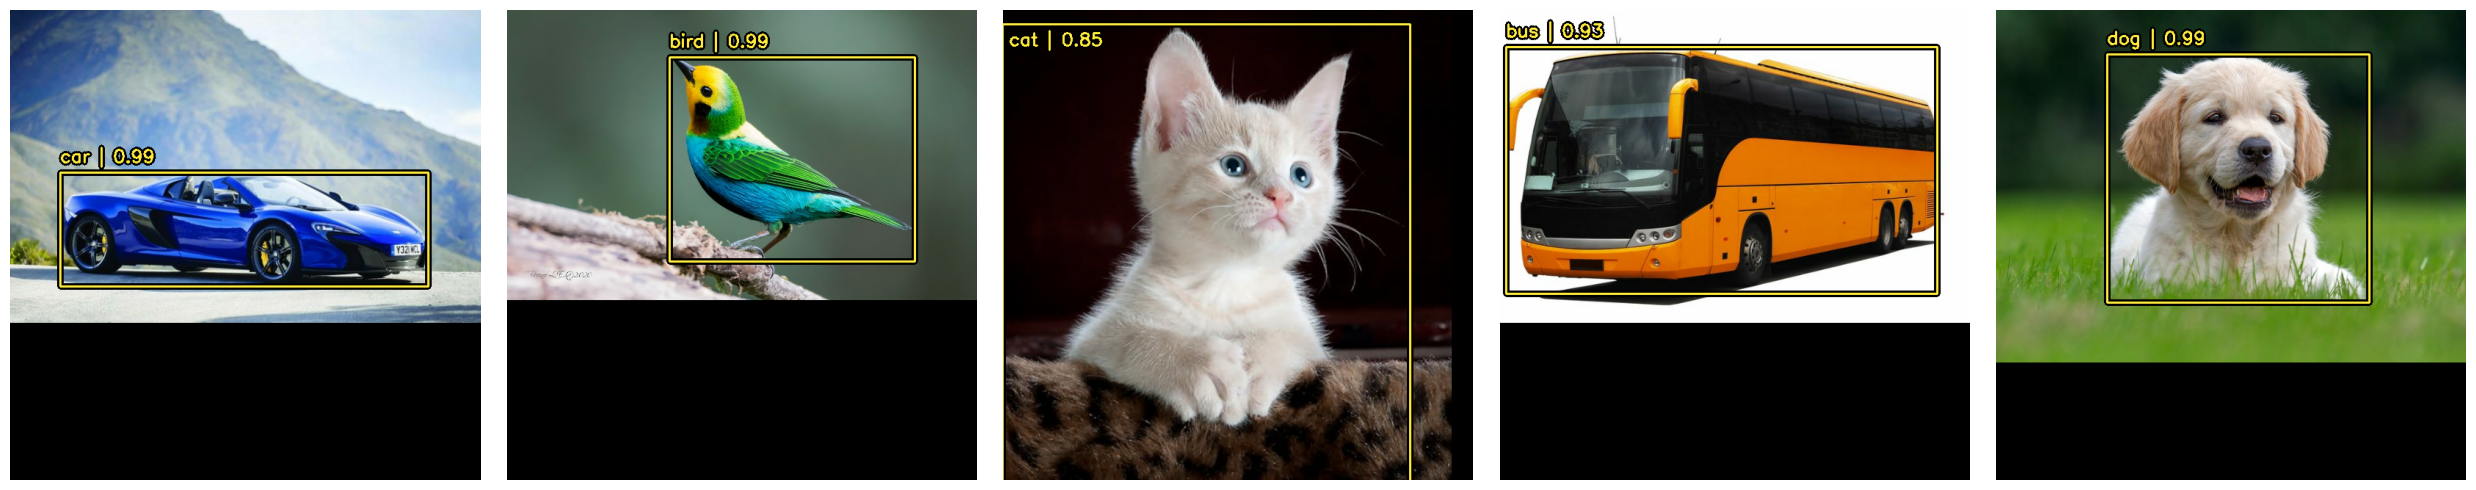

In [12]:
import matplotlib.pyplot as plt

print("Detecting objects...")
predictions = model.predict(image_batch)
class_mapping = {
    0: 'aeroplane', 1: 'bicycle', 2: 'bird', 3: 'boat', 4: 'bottle',
    5: 'bus', 6: 'car', 7: 'cat', 8: 'chair', 9: 'cow',
    10: 'diningtable', 11: 'dog', 12: 'horse', 13: 'motorbike',
    14: 'person', 15: 'pottedplant', 16: 'sheep', 17: 'sofa',
    18: 'train', 19: 'tvmonitor'
}



keras_cv.visualization.plot_bounding_box_gallery(
    image_batch,
    value_range=(0, 255),
    rows=1,
    cols=5,
    y_pred=predictions,
    scale=5,
    font_scale=0.8,
    bounding_box_format="xywh",
    class_mapping=class_mapping,
)
plt.show()

### Step 6: Observation and Analysis

| Image Name | Object Detected | Confidence Score | Accuracy (Correct/Incorrect) |
|------------|-----------------|------------------|-----------------------------|
| car.jpg    | Car             | 0.99             | Correct                     |
| bird.jpg   | Bird            | 0.99             | Correct                     |
| cat.jpg    | Cat             | 0.85             | Correct                     |
|bus.jpg     | bus             | 0.93             | Correct                     |
| dog.jpg    | Dog             | 0.99             | Correct                     |